# J3AM — Micro-Autograd Fonctionnel
## Rétropropagation depuis Zéro — Style Déclaratif

Implémentation d'un moteur de différentiation automatique scalaire.

L'approche est **fonctionnelle** :
- `Value` est une dataclasse **sans méthodes de calcul**
- Les opérateurs sont de simples **fonctions factory** (`add`, `mul`, …) qui construisent le graphe
- `backward` est une **fonction indépendante**

In [1]:
from __future__ import annotations
import math
from dataclasses import dataclass, field
from typing import Callable

## 1. `Value` — Dataclasse

`Value` est un simple conteneur de données. Aucune logique de calcul ici.

| Champ | Rôle |
|---|---|
| `data` | Valeur numérique du nœud |
| `grad` | Gradient accumulé (initialisé à `0.0`) |
| `_prev` | Nœuds parents dans le graphe de calcul |
| `_backward` | Fermeture qui propage le gradient local (assignée par les factories) |

In [2]:
@dataclass(eq=False)  # eq=False : hash par identité, les nœuds sont uniques
class Value:
    """Nœud du graphe de calcul : scalaire + gradient accumulé."""
    data: float
    grad: float = 0.0
    _prev: tuple[Value, ...] = field(default_factory=tuple, repr=False)
    _op:   str               = field(default="",            repr=False)
    _backward: Callable[[], None] | None = field(default=None, repr=False)

# Représentation lisible
Value(2.0)

Value(data=2.0, grad=0.0)

## 2. Opérateurs — Fonctions Factory

**Chain rule** : si $L = f(g(x))$, alors

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial g} \cdot \frac{\partial g}{\partial x}$$

Chaque `_bwd` applique cette règle localement :

$$\texttt{a.grad} \mathrel{+}= \underbrace{\texttt{out.grad}}_{\partial L/\partial \text{out}} \cdot \underbrace{\frac{\partial\, \text{out}}{\partial a}}_{\text{dérivée locale}}$$

On accumule (`+=`) car un même nœud peut apparaître plusieurs fois dans le graphe.

---

Chaque fonction factory :
1. Calcule `out.data` (forward)
2. Définit `_bwd` : la règle de rétropropagation locale
3. Assigne `out._backward = _bwd`
4. Retourne le nouveau nœud `out`

### Primitives

$$\frac{\partial}{\partial a}(a + b) = 1 \qquad \frac{\partial}{\partial b}(a + b) = 1$$

$$\frac{\partial}{\partial a}(a \cdot b) = b \qquad \frac{\partial}{\partial b}(a \cdot b) = a$$

$$\frac{\partial}{\partial a} a^n = n \cdot a^{n-1}$$

In [3]:
def add(a: Value, b: Value) -> Value:
    out = Value(a.data + b.data, _prev=(a, b), _op="+")

    def _bwd():
        a.grad += out.grad
        b.grad += out.grad

    out._backward = _bwd
    return out


def mul(a: Value, b: Value) -> Value:
    out = Value(a.data * b.data, _prev=(a, b), _op="*")

    def _bwd():
        a.grad += b.data * out.grad
        b.grad += a.data * out.grad

    out._backward = _bwd
    return out


def power(a: Value, n: float) -> Value:
    out = Value(a.data ** n, _prev=(a,), _op=f"**{n}")

    def _bwd():
        a.grad += n * a.data ** (n - 1) * out.grad

    out._backward = _bwd
    return out


# Dérivées : combinaisons des primitives
def neg(a: Value)           -> Value: return mul(a, Value(-1.0))
def sub(a: Value, b: Value) -> Value: return add(a, neg(b))
def div(a: Value, b: Value) -> Value: return mul(a, power(b, -1.0))

### Activations & fonctions mathématiques

$$\frac{\partial}{\partial a} \text{relu}(a) = \begin{cases} 1 & a > 0 \\ 0 & a \leq 0 \end{cases}$$

$$\frac{\partial}{\partial a} e^a = e^a \qquad \frac{\partial}{\partial a} \ln(a) = \frac{1}{a}$$

`sigmoid` est une composition des primitives — le graphe retrouve son gradient automatiquement :

$$\sigma(a) = \frac{1}{1+e^{-a}}$$

In [4]:
def relu(a: Value) -> Value:
    out = Value(max(0.0, a.data), _prev=(a,), _op="relu")

    def _bwd():
        a.grad += (out.data > 0) * out.grad

    out._backward = _bwd
    return out


def exp(a: Value) -> Value:
    val = math.exp(a.data)
    out = Value(val, _prev=(a,), _op="exp")

    def _bwd():
        a.grad += val * out.grad      # d/dx exp(x) = exp(x)

    out._backward = _bwd
    return out


def log(a: Value) -> Value:
    out = Value(math.log(a.data), _prev=(a,), _op="log")

    def _bwd():
        a.grad += out.grad / a.data   # d/dx log(x) = 1/x

    out._backward = _bwd
    return out


# Composition des primitives — pas de _bwd explicite
def sigmoid(a: Value) -> Value:
    return div(Value(1.0), add(Value(1.0), exp(neg(a))))

### Réductions & Loss

Toutes construites par composition — le graphe gère les gradients automatiquement.

$$\text{sum}(a) = a_1 + \cdots + a_n \qquad \text{mean}(a) = \frac{\text{sum}(a)}{n}$$

$$\text{MSE} = \text{mean}\bigl((\hat{y}_i - y_i)^2\bigr)$$

In [5]:
def sum(values: list[Value]) -> Value:
    result = Value(0.0)
    for v in values:
        result = add(result, v)
    return result


def mean(values: list[Value]) -> Value:
    return div(sum(values), Value(float(len(values))))


def mse(preds: list[Value], targets: list[float]) -> Value:
    errors = [power(sub(p, Value(t)), 2.0) for p, t in zip(preds, targets)]
    return mean(errors)

## 3. `backward` — Propagation Inverse

Tri topologique du graphe, puis appel des `_backward` en ordre inverse.

In [6]:
def backward(v: Value) -> None:
    """Rétropropagation depuis le nœud `v` vers toutes ses entrées."""
    topo: list[Value] = []
    visited: set[Value] = set()

    def build(node: Value) -> None:
        if node not in visited:
            visited.add(node)
            for child in node._prev:
                build(child)
            topo.append(node)

    build(v)
    v.grad = 1.0
    for node in reversed(topo):
        if node._backward:
            node._backward()

## 4. Forward Pass — Tests des Opérations

In [7]:
x = Value(2.0)
y = Value(-3.0)

assert add(x, y).data   == -1.0
assert mul(x, y).data   == -6.0
assert power(x, 3).data ==  8.0
assert neg(x).data      == -2.0
assert sub(x, y).data   ==  5.0
assert abs(div(x, Value(4.0)).data - 0.5) < 1e-9

assert relu(Value(-1.0)).data == 0.0
assert relu(Value( 3.0)).data == 3.0
assert abs(exp(Value(0.0)).data    - 1.0) < 1e-9
assert abs(log(Value(math.e)).data - 1.0) < 1e-9

print("Opérations forward : OK ✓")

Opérations forward : OK ✓


## 5. Backward Pass — Gradients Manuels

In [8]:
# f(x, y) = x·y + x
# ∂f/∂x = y + 1 = -3 + 1 = -2
# ∂f/∂y = x     = 2
x, y = Value(2.0), Value(-3.0)
z = add(mul(x, y), x)
backward(z)

print(f"z  = x·y + x = {z.data}   (attendu : {2*(-3)+2})")
print(f"∂z/∂x = {x.grad:.1f}   (attendu : {-3+1:.1f})")
print(f"∂z/∂y = {y.grad:.1f}    (attendu : 2.0)")
assert abs(x.grad + 2.0) < 1e-9
assert abs(y.grad - 2.0) < 1e-9

z  = x·y + x = -4.0   (attendu : -4)
∂z/∂x = -2.0   (attendu : -2.0)
∂z/∂y = 2.0    (attendu : 2.0)


In [9]:
# f(x) = relu(x² - 4)  à x = 3
# = relu(5) = 5  |  f'(3) = relu'(5) · 2x = 1 · 6 = 6
x = Value(3.0)
y = relu(sub(power(x, 2), Value(4.0)))
backward(y)

print(f"y = relu(x²-4) = {y.data}  (attendu : 5.0)")
print(f"∂y/∂x = {x.grad:.1f}         (attendu : 6.0)")
assert abs(x.grad - 6.0) < 1e-9

y = relu(x²-4) = 5.0  (attendu : 5.0)
∂y/∂x = 6.0         (attendu : 6.0)


## 6. Vérification Numérique des Gradients

$$\frac{\partial f}{\partial x_i} \approx \frac{f(x_i + \varepsilon) - f(x_i - \varepsilon)}{2\varepsilon}$$

On compare cette estimation au gradient calculé par autograd.

In [10]:
def grad_check(
    f: Callable[..., Value],
    inputs: list[float],
    eps: float = 1e-5,
    tol: float = 1e-4,
) -> None:
    """Vérifie les gradients autograd par différences finies centrées."""
    vals = [Value(x) for x in inputs]
    out  = f(*vals)
    backward(out)
    ag = [v.grad for v in vals]

    print(f"  {'var':<6} {'autograd':>12} {'numérique':>12} {'ok':>4}")
    print(f"  {'-'*38}")
    for i, (a, inp) in enumerate(zip(ag, inputs)):
        ip = inputs[:]; ip[i] += eps
        im = inputs[:]; im[i] -= eps
        ng = (f(*[Value(x) for x in ip]).data - f(*[Value(x) for x in im]).data) / (2 * eps)
        ok = abs(a - ng) < tol
        print(f"  x_{i:<4} {a:>12.6f} {ng:>12.6f} {'✓' if ok else '✗':>4}")
        assert ok, f"x_{i}: autograd={a:.6f} vs numérique={ng:.6f}"
    print()

In [11]:
print("f(x, y) = mul(x, y)")
grad_check(lambda x, y: mul(x, y), [2.0, -3.0])

print("f(x) = power(x, 3)")
grad_check(lambda x: power(x, 3), [2.0])

print("f(x) = exp(x)")
grad_check(lambda x: exp(x), [1.0])

print("f(x) = log(x)")
grad_check(lambda x: log(x), [2.0])

print("f(x) = relu(x)  [x > 0]")
grad_check(lambda x: relu(x), [1.5])

print("f(x, y) = relu(add(mul(x, y), x))")
grad_check(lambda x, y: relu(add(mul(x, y), x)), [1.0, 1.0])

print("Tous les gradients vérifiés ✓")

f(x, y) = mul(x, y)
  var        autograd    numérique   ok
  --------------------------------------
  x_0       -3.000000    -3.000000    ✓
  x_1        2.000000     2.000000    ✓

f(x) = power(x, 3)
  var        autograd    numérique   ok
  --------------------------------------
  x_0       12.000000    12.000000    ✓

f(x) = exp(x)
  var        autograd    numérique   ok
  --------------------------------------
  x_0        2.718282     2.718282    ✓

f(x) = log(x)
  var        autograd    numérique   ok
  --------------------------------------
  x_0        0.500000     0.500000    ✓

f(x) = relu(x)  [x > 0]
  var        autograd    numérique   ok
  --------------------------------------
  x_0        1.000000     1.000000    ✓

f(x, y) = relu(add(mul(x, y), x))
  var        autograd    numérique   ok
  --------------------------------------
  x_0        2.000000     2.000000    ✓
  x_1        1.000000     1.000000    ✓

Tous les gradients vérifiés ✓


## 7. Mini Régression Linéaire

$$\hat{y} = w \cdot x + b \qquad \mathcal{L} = \text{MSE}(\hat{y}, y)$$

15 points bruités générés depuis $y = 2x + 1$. On trace la courbe de loss et la droite apprise.

In [12]:
import random
import matplotlib.pyplot as plt

random.seed(42)

# Dataset : y = 2x + 1 + bruit
n = 15
X = [random.uniform(0, 5) for _ in range(n)]
Y = [2 * x + 1 + random.gauss(0, 0.4) for x in X]

In [13]:
class LinearRegression:
    def __init__(self):
        self.w = Value(0.0)
        self.b = Value(0.0)

    def forward(self, x: float) -> Value:
        return add(mul(self.w, Value(x)), self.b)

    def parameters(self) -> list[Value]:
        return [self.w, self.b]

    def zero_grad(self) -> None:
        for p in self.parameters():
            p.grad = 0.0

In [14]:
model   = LinearRegression()
lr      = 0.01
history = []

for epoch in range(100):
    preds = [model.forward(x) for x in X]
    loss  = mse(preds, Y)
    history.append(loss.data)

    model.zero_grad()
    backward(loss)

    for p in model.parameters():
        p.data -= lr * p.grad

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}  loss={loss.data:.4f}  w={model.w.data:.3f}  b={model.b.data:.3f}")

print(f"\nRésultat : w={model.w.data:.3f} (attendu ≈ 2.0)  b={model.b.data:.3f} (attendu ≈ 1.0)")

epoch   0  loss=30.7472  w=0.257  b=0.096
epoch  20  loss=0.4112  w=1.942  b=0.761
epoch  40  loss=0.2422  w=2.050  b=0.848
epoch  60  loss=0.2337  w=2.045  b=0.887
epoch  80  loss=0.2277  w=2.034  b=0.920

Résultat : w=2.025 (attendu ≈ 2.0)  b=0.947 (attendu ≈ 1.0)


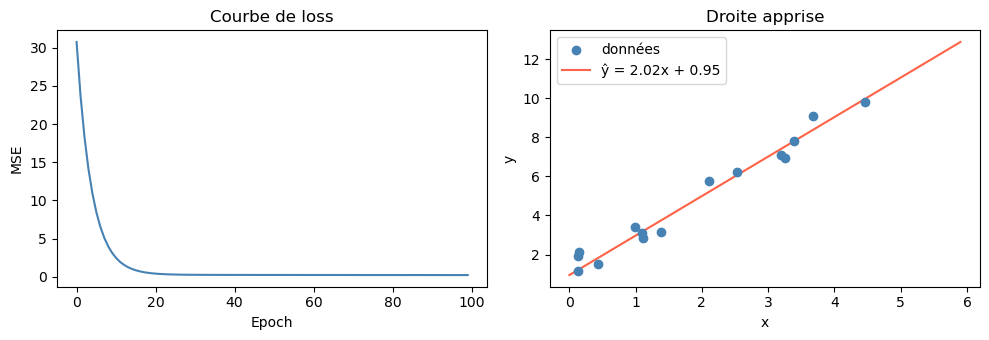

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Courbe de loss
axes[0].plot(history, color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Courbe de loss")

# Droite apprise
x_plot = [i * 0.1 for i in range(60)]
y_plot = [model.forward(x).data for x in x_plot]
axes[1].scatter(X, Y, color="steelblue", label="données", zorder=3)
axes[1].plot(x_plot, y_plot, color="tomato", label=f"ŷ = {model.w.data:.2f}x + {model.b.data:.2f}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Droite apprise")
axes[1].legend()

plt.tight_layout()
plt.show()